<h3 style="color:#6FA8DC; font-weight:bold">Student Placement Prediction - End-to-End ML Project</h3>

This notebook builds a complete **Machine Learning classification project** to predict whether a student is likely to get placed based on:

```text
cgpa
iq
```

The target/output is:

```text
placement
```

where:

```text
1 → Placed
0 → Not Placed
```

We will go through the complete ML workflow step by step.

<br>

### Important idea

We are not going to simply write code and move on.

After every important step, we will understand:

- **what the code does**
- **why we are doing it**
- **what happens internally**
- **why the next step is needed**
- **how this connects to the complete ML pipeline**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


<h5 style="color:#78B89A; font-weight:bold;">Why are we importing these libraries?</h5>

Before working with the dataset, we import the libraries required for this project.

### `pandas`

```python
import pandas as pd
```

Pandas is used to work with tabular data.

For example:

```text
CGPA   IQ   Placement
6.8    123      1
5.9    106      0
7.4    132      1
```

Pandas lets us read, inspect, clean and manipulate this type of data.

### `numpy`

```python
import numpy as np
```

NumPy is used for numerical operations and arrays. We may not need many NumPy operations in this small project, but it is a common library in ML workflows.

### `matplotlib`

```python
import matplotlib.pyplot as plt
```

Matplotlib is used to visualize our data.

<br>

**In short:**

```text
Pandas      → work with dataset
NumPy       → numerical operations
Matplotlib  → visualization
```


<h5 style="color:#78B89A; font-weight:bold;">Project Folder Structure</h5>

We assume the project has this structure:

```text
ML/
└── Student Placement Prediction/
    ├── student-placement-prediction.ipynb
    └── placement.csv
```

Therefore, our CSV path is:

```text
    
placement.csv
```



<h5 style="color:#78B89A; font-weight:bold;">Step 1 - Load the Dataset</h5>

We first need to bring the CSV data into Python.

### Code

```python
df = pd.read_csv("placement.csv")
```

`pd.read_csv()` reads a CSV file and converts it into a **Pandas DataFrame**.

A DataFrame is basically a table in Python.

Flow:

```text
placement.csv
     ↓
pd.read_csv()
     ↓
DataFrame
     ↓
df
```

So after this line:

```python
df = pd.read_csv("placement.csv")
```

`df` contains our complete student placement dataset.



In [2]:
df = pd.read_csv("placement.csv")

print(df.head())


   Unnamed: 0  cgpa     iq  placement
0           0   6.8  123.0          1
1           1   5.9  106.0          0
2           2   5.3  121.0          0
3           3   7.4  132.0          1
4           4   5.8  142.0          0


<h5 style="color:#78B89A; font-weight:bold;">Understanding `head()`</h5>

```python
df.head()
```

shows the first 5 rows by default.

We use it because we should **look at the data before doing anything with it**.

For our dataset, the important columns are:

```text
cgpa
iq
placement
```

Example:

```text
cgpa    iq    placement
6.8     123       1
5.9     106       0
5.3     121       0
7.4     132       1
5.8     142       0
```

Here:

- `cgpa` → student's CGPA
- `iq` → student's IQ
- `placement` → whether the student was placed

We should never blindly train a model without first understanding what the columns represent.


<h5 style="color:#78B89A; font-weight:bold;">Step 2 — Check the Dataset Shape</h5>

Before training a model, we should know how much data we have.

### Code

```python
df.shape
```

`shape` gives:

```text
(number of rows, number of columns)
```

For example, if the result is:

```text
(100, 4)
```

it means:

```text
100 rows
4 columns
```

A row represents one student's record.

A column represents one feature or piece of information.



In [3]:
print("Shape of dataset:", df.shape)


Shape of dataset: (100, 4)


<h5 style="color:#78B89A; font-weight:bold;">Step 3 — Understand the Dataset</h5>

Now we inspect the dataset more carefully.

Useful commands are:

```python
df.info()
df.describe()
```

### `df.info()`

This tells us:

- number of rows
- column names
- data types
- whether values are missing

### `df.describe()`

This gives statistical information such as:

- count
- mean
- standard deviation
- minimum
- maximum

This step is important because ML models need **clean and appropriate input data**.

Before training, we should know what kind of data we are giving to the model.


In [ ]:
df.info()

print("\nStatistical Summary:")
print(df.describe())


<h5 style="color:#78B89A; font-weight:bold;">Step 4 — Remove an Unnecessary Column</h5>

If the CSV contains a column such as:

```text
Unnamed: 0
```

it is usually just an automatically saved index and does not represent useful student information.

We remove it:

```python
df = df.iloc[:, 1:]
```

### Understanding this line

```python
df.iloc[:, 1:]
```

means:

```text
:     → take all rows
1:    → take columns starting from index 1
```

So column index `0` is removed.

After this, we keep the actual project columns:

```text
cgpa
iq
placement
```

### Why remove it?

Because an irrelevant column should not be given to the model.

We want the model to learn from meaningful information, not from an accidental row/index number.


In [4]:
df = df.iloc[:, 1:]

print(df.head())
print("\nColumns:", df.columns.tolist())


   cgpa     iq  placement
0   6.8  123.0          1
1   5.9  106.0          0
2   5.3  121.0          0
3   7.4  132.0          1
4   5.8  142.0          0

Columns: ['cgpa', 'iq', 'placement']


<h5 style="color:#78B89A; font-weight:bold;">Step 5 — Check for Missing Values</h5>

Machine Learning models generally cannot directly work with unexpected missing values.

So we check:

```python
df.isnull().sum()
```

This tells us how many missing values exist in each column.

For example:

```text
cgpa         0
iq           0
placement    0
```

means there are no missing values.

If missing values existed, we would need to decide how to handle them before training.


In [5]:
print(df.isnull().sum())


cgpa         0
iq           0
placement    0
dtype: int64


<h5 style="color:#78B89A; font-weight:bold;">Step 6 - Separate Input Features and Output</h5>

Now we reach one of the most important ML concepts.

Our dataset contains:

```text
cgpa
iq
placement
```

But the model should use:

```text
cgpa + iq
```

to predict:

```text
placement
```

So we separate the dataset into:

```text
X → Input features
y → Target/output
```

### Code

```python
X = df.iloc[:, 0:2]
y = df.iloc[:, -1]
```

Here:

```text
X = cgpa, iq
y = placement
```

### Think of it as a question

We are asking the model:

> "If I give you a student's CGPA and IQ, can you predict whether the student will be placed?"

Therefore:

```text
INPUT
   ↓
CGPA + IQ
   ↓
ML MODEL
   ↓
OUTPUT
   ↓
Placement
```

This is the basic structure of supervised learning.


In [6]:
X = df.iloc[:,:-1]
y = df.iloc[:, -1]

print("X:")
print(X.head())

print("\ny:")
print(y.head())


X:
   cgpa     iq
0   6.8  123.0
1   5.9  106.0
2   5.3  121.0
3   7.4  132.0
4   5.8  142.0

y:
0    1
1    0
2    0
3    1
4    0
Name: placement, dtype: int64


<h5 style="color:#78B89A; font-weight:bold;">Understanding X and y Clearly</h5>

Suppose one row is:

```text
CGPA = 6.8
IQ = 123
Placement = 1
```

We give the model:

```text
X = [6.8, 123]
```

and tell it the correct answer:

```text
y = 1
```

The model studies many such examples.

For example:

```text
CGPA    IQ     Placement
6.8     123       1
5.9     106       0
7.4     132       1
```

The model tries to learn a relationship between:

```text
X → y
```

That is why:

```text
X = features/input
y = target/output
```

⭐ This distinction is fundamental in almost every supervised ML project.


<h5 style="color:#78B89A; font-weight:bold;">Step 7 — Split the Data into Training and Testing Data</h5>

We should **not train and test the model on exactly the same data**.

Instead, we divide our data into two parts:

```text
Training data → used to learn
Testing data  → used to evaluate
```

### Code

```python
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.1,
    random_state=42
)
```

Here:

```python
test_size=0.1
```

means **10% of the data is kept for testing**.

If there are 100 rows:

```text
100 total
│
├── 90 → training
└── 10 → testing
```

### Is 90 - 10 a general rule?

No.

There is no compulsory ratio.

Common choices include:

```text
80% train / 20% test
70% train / 30% test
90% train / 10% test
```

The ratio depends on the amount and nature of the data.

In this notebook, `0.1` simply means we are choosing 10% as the test set.

### Why do we need two sets?

Imagine studying for an exam.

If you study the questions and then get exactly the same questions in the exam, getting them right does not prove that you can solve new questions.

Similarly:

```text
Training data
    ↓
Model learns

Test data
    ↓
Model faces unseen examples
```

This gives us a better idea of how the model performs on new data.

### What does `random_state=42` do?

It makes the random split reproducible.

Without it, the rows selected for training/testing can change each time we run the notebook.

With:

```python
random_state=42
```

we get the same split each time, making our experiment easier to reproduce.


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.1,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)


X_train shape: (90, 2)
X_test shape : (10, 2)
y_train shape: (90,)
y_test shape : (10,)


<h5 style="color:#78B89A; font-weight:bold;">Understanding the Four Variables</h5>

After splitting, we have four pieces:

```text
X_train → input features used for learning
y_train → correct answers used for learning

X_test  → unseen input features
y_test  → correct answers used for checking predictions
```

The relationship is:

```text
X_train  ↔  y_train
X_test   ↔  y_test
```

For example:

```text
X_train:
CGPA   IQ

y_train:
0 / 1
```

The model learns from these pairs.

Later:

```text
X_test
   ↓
Model
   ↓
prediction
```

We compare that prediction with:

```text
y_test
```

⭐ This is why we keep `y_test`: it contains the actual answers against which we can evaluate the model.


<h5 style="color:#78B89A; font-weight:bold;">Step 8 — Feature Scaling</h5>

Now we need to discuss an important question:

### Why scale the data?

Look at the ranges of our features:

```text
CGPA → approximately 5–10
IQ   → approximately 80–160
```

They are measured on very different numerical scales.

A model such as Logistic Regression uses mathematical calculations involving these features.

Scaling converts the features into a more comparable numerical scale.

We use:

```python
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
```

### The most important rule

We **split first and scale second**.

Correct order:

```text
Original data
     ↓
Split into train/test
     ↓
Fit scaler using X_train only
     ↓
Transform X_train
     ↓
Transform X_test using the SAME scaler
```

### Why not scale before splitting?

Because the scaler calculates information such as the mean and standard deviation.

If we let it calculate those values using the entire dataset, information from the test data would influence the preprocessing.

That is called **data leakage**.

The test set is supposed to remain unseen while we prepare/train the model.



In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)


<h5 style="color:#78B89A; font-weight:bold;">Understanding `fit_transform()`</h5>

This line is extremely important:

```python
X_train = scaler.fit_transform(X_train)
```

Think of the scaler as a machine that first needs to learn its rules.

### `fit`

```text
fit = LEARN
```

The scaler looks at **X_train** and learns the required scaling information.

For StandardScaler, this includes the mean and standard deviation of each feature.

### `transform`

```text
transform = APPLY
```

It then applies those learned rules to the data.

### `fit_transform`

```text
fit_transform = fit + transform
```

So:

```python
scaler.fit_transform(X_train)
```

means:

> Learn the scaling rules from the training data and then scale the training data using those rules.

⭐ The scaler learns from **training data only**.


In [9]:
X_test = scaler.transform(X_test)


<h5 style="color:#78B89A; font-weight:bold;">Why do we transform X_test?</h5>

This is one of the most commonly misunderstood parts of the ML pipeline.

We **DO need to scale X_test**.

But we **DO NOT fit the scaler on X_test**.

We already learned the scaling rules from the training data:

```python
scaler.fit_transform(X_train)
```

Now the test data must be represented using the **same rules**, because the model will be tested using that representation.

Therefore:

```python
X_test = scaler.transform(X_test)
```

means:

> Do not learn new scaling information. Use the scaling rules already learned from X_train and apply them to X_test.

### Correct

```text
X_train
   ↓
fit + transform
   ↓
scaled X_train

X_test
   ↓
transform only
   ↓
scaled X_test
```

### Incorrect

```python
X_test = scaler.fit_transform(X_test)
```

That would make the scaler learn a separate set of rules from the test data.

### Easy memory trick

```text
TRAIN → fit_transform
TEST  → transform
```

Or:

```text
Training data TEACHES the scaler.
Test data only USES the scaler.
```

This keeps the test set independent and prevents preprocessing leakage.


<h5 style="color:#78B89A; font-weight:bold;">What Actually Happens During Standard Scaling?</h5>

StandardScaler uses the idea:

```text
scaled value = (original value - mean) / standard deviation
```

The purpose is to represent values relative to the feature's distribution.

After scaling, the numerical values of CGPA and IQ are on a comparable standardized scale.

### Important

Scaling does **not** mean:

```text
8 CGPA becomes a real CGPA of 0.5
```

The original data is still conceptually the same.

Scaling simply changes the numerical representation that is supplied to the model.



<h5 style="color:#78B89A; font-weight:bold;">Step 9 — Visualize the Data</h5>

Before training, it is useful to visually understand the relationship between our two input features.

We can plot:

```text
CGPA vs IQ
```

and use the placement value to distinguish the classes.



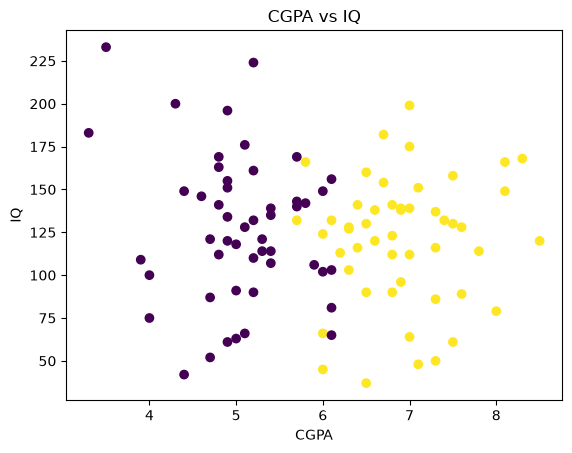

In [10]:
plt.scatter(df["cgpa"], df["iq"], c=df["placement"])

plt.xlabel("CGPA")
plt.ylabel("IQ")
plt.title("CGPA vs IQ")
plt.show()


<h5 style="color:#78B89A; font-weight:bold;">Understanding the Scatter Plot</h5>

Each point represents one student.

The horizontal axis represents:

```text
CGPA
```

The vertical axis represents:

```text
IQ
```

The placement value is used to distinguish the classes.

The purpose of this plot is not to train the model.

It is an **EDA (Exploratory Data Analysis)** step.

We are asking:

> "Do the input features appear to contain some relationship with placement?"

If the classes show some separation, a classification model may be able to learn a useful decision boundary.



<h5 style="color:#78B89A; font-weight:bold;">Step 10 - Choose the Machine Learning Model</h5>

Our target is:

```text
placement
```

and its values are:

```text
0 → Not Placed
1 → Placed
```

This is a **binary classification problem** because there are two possible classes.

For this project, we use:

```text
Logistic Regression
```

### Code

```python
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()
```

### Why Logistic Regression?

Despite the word "Regression" in its name, Logistic Regression is commonly used for **classification**.

It estimates the probability of belonging to a class and then produces a class prediction.

In our case:

```text
CGPA + IQ
   ↓
Logistic Regression
   ↓
Probability / decision
   ↓
0 or 1
```

So:

```text
0 → Not Placed
1 → Placed
```


In [11]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()


<h5 style="color:#78B89A; font-weight:bold;">Step 11 - Train the Model</h5>

Now we finally train the ML model.

### Code

```python
clf.fit(X_train, y_train)
```

This is where the model actually learns from our training data.

Remember:

```text
X_train → student information
y_train → correct placement answers
```

The model looks at many examples and learns mathematical parameters that help it connect:

```text
CGPA + IQ
     ↓
Placement
```

### Very important distinction

There are two different `fit()` ideas in this notebook:

```python
scaler.fit(...)
```

and:

```python
clf.fit(...)
```

They are not the same thing.

```text
scaler.fit()
→ scaler learns how to scale data

clf.fit()
→ ML model learns the relationship between X and y
```

This distinction is extremely important.


In [12]:
clf.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

<h5 style="color:#78B89A; font-weight:bold;">What Does "Learning" Mean Here?</h5>

The model is not learning like a human student memorizing sentences.

It is performing mathematical optimization.

Very simply:

```text
Training examples
      ↓
Model calculations
      ↓
Adjust internal parameters
      ↓
Try to reduce prediction errors
      ↓
Learn a useful mathematical relationship
```

For Logistic Regression, the learned relationship can be thought of as a mathematical decision function involving the input features.

We do not manually calculate these parameters.

Scikit-learn handles the optimization when we call:

```python
clf.fit(X_train, y_train)
```



<h5 style="color:#78B89A; font-weight:bold;">Step 12 - Make Predictions on Test Data</h5>

The model has now been trained.

We can give it the **unseen test features**:

```python
y_pred = clf.predict(X_test)
```

The model uses what it learned during training to produce predictions.

Flow:

```text
X_test
   ↓
Trained model
   ↓
y_pred
```

`y_pred` contains the model's predicted class:

```text
0 → predicted not placed
1 → predicted placed
```

We have not given the model `y_test` while making these predictions.

That is important because `y_test` contains the actual answers we want to use for evaluation.


In [13]:
y_pred = clf.predict(X_test)

print("Predicted values:")
print(y_pred)


Predicted values:
[1 1 1 0 1 0 0 0 0 1]


<h5 style="color:#78B89A; font-weight:bold;">Step 13 - Compare Predictions with Actual Answers</h5>

Now we have two things:

```text
y_pred → model's predictions
y_test → actual answers
```

For example:

```text
y_test = [1, 0, 1, 1, 0]
y_pred = [1, 0, 0, 1, 0]
```

Compare them:

```text
Actual     Predicted
  1           1       ✓
  0           0       ✓
  1           0       ✗
  1           1       ✓
  0           0       ✓
```

The model got 4 out of 5 correct in this example.

This comparison is the basis of evaluation.



In [14]:
print("Actual values:")
print(y_test.to_numpy())

print("\nPredicted values:")
print(y_pred)


Actual values:
[1 1 1 1 1 0 0 0 1 1]

Predicted values:
[1 1 1 0 1 0 0 0 0 1]


<h5 style="color:#78B89A; font-weight:bold;">Step 14 - Evaluate the Model Using Accuracy</h5>

One simple evaluation metric for this binary classification problem is **accuracy**.

### Code

```python
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
```

Accuracy means:

```text
number of correct predictions
--------------------------------
total number of predictions
```

For example, if:

```text
10 test students
9 predictions correct
```

then:

```text
accuracy = 9 / 10 = 0.90
```

or:

```text
90%
```

### Important limitation in this project

Our dataset is small and we are using only 10% as test data.

If there are 10 test examples:

```text
1 correct/incorrect prediction
```

changes the accuracy by:

```text
10 percentage points
```

So we should not treat one accuracy number from such a small test set as proof that the model is perfect.



In [15]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)


Accuracy: 0.8


<h5 style="color:#78B89A; font-weight:bold;">Step 15 — Understand the Complete Prediction Flow</h5>

At this point, the complete project can be understood as:

```text
Student Dataset
      ↓
Clean / inspect data
      ↓
Separate X and y
      ↓
Split train/test
      ↓
Fit scaler on X_train
      ↓
Transform X_train
      ↓
Transform X_test using same scaler
      ↓
Create Logistic Regression
      ↓
Train with X_train + y_train
      ↓
Predict X_test
      ↓
Compare y_pred with y_test
      ↓
Calculate accuracy
```

This is the basic **end-to-end supervised Machine Learning workflow**.



<h5 style="color:#78B89A; font-weight:bold;">Step 16 - Predict for a New Student</h5>

Now suppose a completely new student comes to us.

For example:

```text
CGPA = 8.2
IQ   = 150
```

We want the model to predict:

```text
Placed or Not Placed?
```

First, the new student's data must be in the same feature format:

```python
new_student = [[8.2, 150]]
```

But remember:

### The model was trained using scaled data.

Therefore, we must scale the new student's features using the **same scaler learned from X_train**.

```python
new_student = scaler.transform(new_student)
```

Then we give it to the trained model:

```python
prediction = clf.predict(new_student)
```

Finally:

```text
1 → predicted placed
0 → predicted not placed
```

### Important

We use:

```python
scaler.transform(new_student)
```

not:

```python
scaler.fit_transform(new_student)
```

because we must use the same scaling rules learned from the training data.


In [16]:
new_student = [[8.2, 150]]

new_student_scaled = scaler.transform(new_student)

prediction = clf.predict(new_student_scaled)

print("Prediction:", prediction[0])

if prediction[0] == 1:
    print("Student is predicted to be placed.")
else:
    print("Student is predicted not to be placed.")


Prediction: 1
Student is predicted to be placed.


c:\Users\devma\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


<h5 style="color:#78B89A; font-weight:bold;">Why Must a New Student Also Be Scaled?</h5>

This follows exactly the same idea as the test data.

The model learned from:

```text
scaled X_train
```

So every future input should be represented in the same way.

The flow is:

```text
New student's raw data
        ↓
Use scaler learned from X_train
        ↓
Scaled new student
        ↓
Trained model
        ↓
Prediction
```

We never create a new scaler for each new student.

⭐ One scaler is learned during training and then reused for future data.


<h3 style="color:#6FA8DC; font-weight:bold;">Final ML Pipeline - Remember This</h3>

The complete project can be remembered using this sequence:

```text
1. Load Data
       ↓
2. Understand / Clean Data
       ↓
3. Separate X and y
       ↓
4. Split Train and Test
       ↓
5. Scale X_train
       ↓
6. Scale X_test using the same scaler
       ↓
7. Choose Model
       ↓
8. Train Model
       ↓
9. Predict
       ↓
10. Evaluate
       ↓
11. Predict on New Data
```

### ⭐ Most important code

```python
# Separate input and output
X = df.iloc[:, 0:2]
y = df.iloc[:, -1]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42
)

# Scale
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model
clf = LogisticRegression()

# Train
clf.fit(X_train, y_train)

# Predict
y_pred = clf.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)
```

### ⭐ Four words to remember

```text
fit()            → LEARN
transform()      → APPLY
fit_transform()  → LEARN + APPLY
predict()        → MAKE PREDICTION
```

### ⭐ Most important scaling rule

```text
Split first
     ↓
fit_transform → X_train
     ↓
transform → X_test
```

**Never fit the scaler using the test set.**

This prevents test-set information from leaking into the training/preprocessing process.


<h5 style="color:#78B89A; font-weight:bold;">What You I Learned from This Project</h5>

By completing this notebook, you have learned the basic end-to-end ML workflow:

- How to load a CSV dataset using Pandas
- How to inspect a dataset
- How to identify input features and the target
- What `X` and `y` mean
- Why data is divided into training and testing sets
- What `test_size` means
- Why 80–20 is common but not a compulsory rule
- Why feature scaling is useful
- Why we split before scaling
- Difference between `fit`, `transform`, and `fit_transform`
- Why the test data is transformed but never used to fit the scaler
- What Logistic Regression is used for
- What model training means
- How predictions are made
- How actual and predicted values are compared
- What accuracy means
- How to make a prediction for a new student

The key mental model is:

```text
DATA
 ↓
X + y
 ↓
TRAIN / TEST SPLIT
 ↓
SCALE
 ↓
TRAIN MODEL
 ↓
PREDICT
 ↓
EVALUATE
```

⭐ This is the foundation we will reuse in many Machine Learning projects.
